In [ ]:
import cv2
from google.colab.patches import cv2_imshow
import numpy as np
import copy

In [ ]:
def ker_loc_sum(i,j,ker_size_X,ker_size_Y,intg_img):
  x1, y1 = i, j
  x2, y2 = i + ker_size_X - 1, j + ker_size_Y - 1
  sums = intg_img[x2, y2]
  if x1 > 0:
    sums -= intg_img[x1 - 1, y2]
  if y1 > 0:
    sums -= intg_img[x2, y1 - 1]
  if x1 > 0 and y1 > 0:
    sums += intg_img[x1 - 1, y1 - 1]
  return sums

In [ ]:
def integral(img):
  intg=np.zeros((np.shape(img)))
  for i in range(np.shape(img)[0]):
    for j in range(np.shape(img)[1]):
      sum=0
      if (i==0 and j==0):
        sum=img[i][j]
      elif (i==0):
        sum=img[i][j]+intg[i][j-1]
      elif (j==0):
        sum=img[i][j]+intg[i-1][j]
      else:
        sum=img[i][j]+intg[i-1][j]+intg[i][j-1]-intg[i-1][j-1]
      intg[i][j]=sum
  return intg


In [ ]:
img = cv2.imread("img.png",0)
intg_img = np.zeros((img.shape[0],img.shape[1]))
for i in range(img.shape[0]):
  for j in range(img.shape[1]):
    intg_img[i][j] = int(img[0:i+1,0:j+1].sum())
intg_img = intg_img.astype(int)
ker_shape = 4
#kernal = np.zeros((ker_shape,ker_shape))
filter1 = {"pos":([(0,2),(2,0)],2),"neg":([(0,0),(2,2)],2)}
filter2 = {"pos":([(2,0),(2,2)],2), "neg":([(0,0),(0,2)],2)}
filter3 = {"pos":([(0,2),(2,2)],2), "neg":([(0,0),(2,0)],2)}
filter4 = {"neg":([(0,2),(2,0)],2),"pos":([(0,0),(2,2)],2)}
filter5 = {"neg":([(0,0),(2,0),(0,2)],2),"pos":([(2,2)],2)}


In [ ]:
def filter_resultant(filter, img, ker_shape):
  result = np.zeros((img.shape[0]-ker_shape + 1,img.shape[1]-ker_shape + 1))
  for i in range(img.shape[0]-ker_shape + 1):
    for j in range(img.shape[1]-ker_shape + 1):
      tot_sum_p = 0
      tot_sum_n = 0
      for k in filter["pos"][0]:
        tot_sum_p += ker_loc_sum(i+k[0] , j+k[1] , filter["pos"][1] , filter["pos"][1] , intg_img)
        #print(tot_sum_p)
      for k in filter["neg"][0]:
        tot_sum_n += ker_loc_sum(i+k[0] , j+k[1] , filter["neg"][1] , filter["neg"][1] , intg_img)
        #print(tot_sum_n)
      result[i,j]=(tot_sum_p - tot_sum_n)
  return result

array([[ 56,   8,  66, ..., 202, 190, 151],
       [ 36,  33, 167, ..., 191, 177, 136],
       [ 22,  50, 152, ..., 146, 180, 183],
       ...,
       [ 16,  17,  17, ..., 130,  87,  64],
       [ 26,  26,  26, ..., 147, 128, 134],
       [ 19,  19,  20, ...,  98, 109, 143]], dtype=uint8)
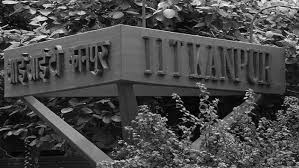

In [ ]:
img

In [ ]:
ker_loc_sum(0,0,1,1,intg_img)

np.int64(56)

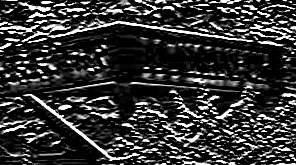

In [ ]:
res = filter_resultant(filter2,img,4)
imgc = np.zeros((res.shape[0],res.shape[1]))
t = 120
for i in range(res.shape[0]):
  for j in range(res.shape[1]):
    if abs(res[i][j]) < t:
      imgc[i][j] = 0
    else:
      imgc[i][j] = 255
cv2_imshow(res)

In [ ]:
print(res)

[[ -219.  -460.  -992. ... -1634. -1694. -1466.]
 [ -720.  -926. -1346. ... -1653. -1449. -1329.]
 [ -654.  -955. -1290. ... -1614. -1452. -1338.]
 ...
 [ -158.  -162.  -164. ...  -323.  -569.  -953.]
 [ -186.  -187.  -190. ...  -186.  -399.  -825.]
 [ -158.  -161.  -164. ...  -357.  -500.  -671.]]


In [ ]:
def conv(img,ker,intg_img):
  fimg=np.zeros((np.shape(img)[0]-3,np.shape(img)[1]-3))
  for i in range(3,img.shape[0]):
    for j in range(3,img.shape[1]):
      fimg[i-3][j-3] = (intg_img[i-3:i+1,j-3:j+1]*ker).sum()
  return fimg

In [ ]:
k2=[[-1, -1, 1, 1],
[-1, -1, 1, 1],
[1, 1, -1, -1],
[1, 1, -1, -1]]
img.shape

(168, 299)

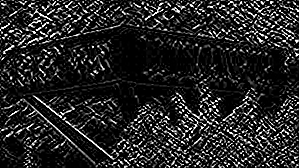

In [ ]:
cv2_imshow(cv2.filter2D(img,-1,np.array(k2)))